# Classificação de Gatos vs Cachorros

Este notebook organiza em etapas o mesmo fluxo de código original: preparação dos dados, treino do modelo, avaliação e teste interativo com imagens.


## 1. Imports e configuração básica

Nesta etapa importamos todas as bibliotecas necessárias e definimos constantes usadas ao longo do notebook (caminhos, tamanho das imagens e *batch size*).

> ⚙️ Agora o notebook detecta automaticamente GPUs disponíveis e configura o TensorFlow para usá-las sempre que possível.

In [2]:
import os
import zipfile
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import load_img, img_to_array

from sklearn.metrics import classification_report, confusion_matrix
from google.colab import files

# Escolhe automaticamente o diretório base (Colab ou ambiente local)
def resolve_data_root():
    candidates = []
    env_root = os.environ.get('DATA_ROOT_PATH')
    if env_root:
        candidates.append(env_root)
    candidates.extend(['/content', os.getcwd()])

    for candidate in candidates:
        if not candidate:
            continue
        candidate = os.path.abspath(candidate)
        test_dir = os.path.join(candidate, '_write_test')
        try:
            os.makedirs(test_dir, exist_ok=True)
            shutil.rmtree(test_dir, ignore_errors=True)
            return candidate
        except PermissionError:
            continue

    raise RuntimeError('Nenhum diretório gravável encontrado. Defina DATA_ROOT_PATH.')

DATA_ROOT = resolve_data_root()

# ---- Configuração de dispositivo (GPU/CPU) ----
try:
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        DEVICE = '/GPU:0'
        print(f'✅ GPU detectada: {gpus[0].name}')
    else:
        DEVICE = '/CPU:0'
        print('⚠️ Nenhuma GPU detectada. Usando CPU.')
except Exception as e:
    DEVICE = '/CPU:0'
    print(f'⚠️ Erro ao configurar GPU. Usando CPU. Detalhes: {e}')

DATASET_SOURCE = os.path.join(DATA_ROOT, 'data_dogs_vs_cats')
SOURCE_CATS_DIR = os.path.join(DATASET_SOURCE, 'cats')
SOURCE_DOGS_DIR = os.path.join(DATASET_SOURCE, 'dogs')

BASE_DIR = os.path.join(DATA_ROOT, 'dataset_final')
IMG_SIZE = (160, 160) # Aumentei um pouco do estipulado para capturar mais detalhes de imagens ruins
BATCH_SIZE = 32
IMG_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.bmp')



2025-12-13 13:12:38.632594: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


✅ GPU detectada: /physical_device:GPU:0


## 2. Preparação da pasta base e extração dos zips

Agora limpamos o diretório base (caso exista), recriamos a estrutura de `train` e `validation` para `cats` e `dogs`,
e em seguida definimos a função `processar_dados` para extrair as imagens dos arquivos zip e distribuí-las entre treino e validação.


In [4]:
if os.path.exists(BASE_DIR):
    shutil.rmtree(BASE_DIR)

for split in ['train', 'validation']:
    for cls in ['cats', 'dogs']:
        os.makedirs(os.path.join(BASE_DIR, split, cls), exist_ok=True)

print("✅ Ambiente limpo e configurado.")

def coletar_imagens(origem_dir):
    imagens = []
    for root, _, files_list in os.walk(origem_dir):
        for f in files_list:
            if f.lower().endswith(IMG_EXTENSIONS):
                imagens.append(os.path.join(root, f))
    return imagens


def processar_dados(origem_dir, classe_nome):
    if not os.path.isdir(origem_dir):
        print(f"❌ PASTA NÃO ENCONTRADA: {origem_dir}")
        return

    print(f"\n📦 Processando {classe_nome} a partir de {origem_dir}...")
    imagens = coletar_imagens(origem_dir)

    if not imagens:
        print(f"⚠️ Nenhuma imagem válida encontrada para {classe_nome}.")
        return

    random.shuffle(imagens)

    split_idx = int(len(imagens) * 0.8)
    train_imgs = imagens[:split_idx]
    val_imgs = imagens[split_idx:]

    print("   -> Copiando arquivos...")
    for f in tqdm(train_imgs, desc=f"Treino {classe_nome}"):
        shutil.copy(f, os.path.join(BASE_DIR, 'train', classe_nome, os.path.basename(f)))

    for f in tqdm(val_imgs, desc=f"Validação {classe_nome}"):
        shutil.copy(f, os.path.join(BASE_DIR, 'validation', classe_nome, os.path.basename(f)))


processar_dados(SOURCE_CATS_DIR, 'cats')
processar_dados(SOURCE_DOGS_DIR, 'dogs')



✅ Ambiente limpo e configurado.

📦 Processando cats a partir de /mnt/c/Users/gugsh/Repos/Estudos/IA/Lista DeepLearning/data_dogs_vs_cats/cats...
   -> Copiando arquivos...


Treino cats:   0%|          | 0/10000 [00:00<?, ?it/s]

Validação cats:   0%|          | 0/2500 [00:00<?, ?it/s]


📦 Processando dogs a partir de /mnt/c/Users/gugsh/Repos/Estudos/IA/Lista DeepLearning/data_dogs_vs_cats/dogs...
   -> Copiando arquivos...


Treino dogs:   0%|          | 0/10000 [00:00<?, ?it/s]

Validação dogs:   0%|          | 0/2500 [00:00<?, ?it/s]

## 3. Verificação de integridade das imagens

Aqui definimos a função `verificar_imagens`, que tenta abrir cada arquivo de imagem com TensorFlow.
Arquivos corrompidos são identificados e removidos, garantindo que o treinamento não quebre no meio.


In [5]:
def verificar_imagens(root_dir):
    print(f"\n🧹 Verificando integridade das imagens em: {root_dir}")
    removidos = 0
    all_files = []

    for root, _, files_list in os.walk(root_dir):
        for f in files_list:
            all_files.append(os.path.join(root, f))

    for path in tqdm(all_files, desc="Verificando"):
        try:
            img_bytes = tf.io.read_file(path)
            tf.io.decode_image(img_bytes, expand_animations=False)
        except Exception as e:
            print(f"   💀 Corrompido detectado e removido: {path}")
            os.remove(path)
            removidos += 1

    print(f"✅ Limpeza concluída. Arquivos removidos: {removidos}")

verificar_imagens(os.path.join(BASE_DIR, 'train'))
verificar_imagens(os.path.join(BASE_DIR, 'validation'))



🧹 Verificando integridade das imagens em: /mnt/c/Users/gugsh/Repos/Estudos/IA/Lista DeepLearning/dataset_final/train


Verificando:   0%|          | 0/20000 [00:00<?, ?it/s]

I0000 00:00:1765642868.890729   91004 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4078 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660 Ti, pci bus id: 0000:01:00.0, compute capability: 7.5


✅ Limpeza concluída. Arquivos removidos: 0

🧹 Verificando integridade das imagens em: /mnt/c/Users/gugsh/Repos/Estudos/IA/Lista DeepLearning/dataset_final/validation


Verificando:   0%|          | 0/5000 [00:00<?, ?it/s]

✅ Limpeza concluída. Arquivos removidos: 0


## 4. Criação dos datasets com `tf.data` e data augmentation

Nesta etapa criamos os datasets de treino e validação a partir das pastas organizadas,
e configuramos *caching*, *prefetch* e um bloco de `data_augmentation` para melhorar a generalização do modelo.


In [6]:
print("\n🚀 Criando Datasets com tf.data...")

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_DIR, 'train'),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    seed=123
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_DIR, 'validation'),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    seed=123
)

class_names = train_ds.class_names
print(f"🗂️ Classes: {class_names}")

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])



🚀 Criando Datasets com tf.data...
Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.
🗂️ Classes: ['cats', 'dogs']


## 5. Definição do modelo CNN e callbacks

Aqui definimos a arquitetura da rede convolucional (`criar_modelo`), compilamos o modelo
e configuramos callbacks para *early stopping*, salvamento do melhor modelo e redução da taxa de aprendizado.


In [7]:
def criar_modelo():
    model = models.Sequential([
        Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
        layers.Rescaling(1./255),

        data_augmentation,

        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

model = criar_modelo()

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

callbacks = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
    ModelCheckpoint('melhor_modelo.keras', monitor='val_accuracy', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)
]


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 160, 160, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 80, 80, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 40, 40, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 20, 20, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 20, 20, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 456,385 (1.74 MB)

 Trainable params: 455,425 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

## 6. Treinamento do modelo

Agora iniciamos o treinamento usando os datasets de treino e validação.
O histórico (`history`) será usado depois para plotar as curvas de perda e acurácia.


In [8]:
print("\n🏋️ Iniciando Treinamento...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks
)



🏋️ Iniciando Treinamento...
Epoch 1/30


2025-12-13 13:23:03.557566: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:17: Filling up shuffle buffer (this may take a while): 382 of 1000
2025-12-13 13:23:12.303323: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.
2025-12-13 13:23:13.175363: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91700


625/625 ━━━━━━━━━━━━━━━━━━━━ 88s 101ms/step - accuracy: 0.6324 - loss: 0.6504 - val_accuracy: 0.6526 - val_loss: 0.6289 - learning_rate: 0.0010
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 116s 186ms/step - accuracy: 0.6925 - loss: 0.5817 - val_accuracy: 0.7080 - val_loss: 0.5568 - learning_rate: 0.0010
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 236s 378ms/step - accuracy: 0.7343 - loss: 0.5321 - val_accuracy: 0.7576 - val_loss: 0.5008 - learning_rate: 0.0010
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 303s 485ms/step - accuracy: 0.7713 - loss: 0.4747 - val_accuracy: 0.7522 - val_loss: 0.4950 - learning_rate: 0.0010
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 327s 523ms/step - accuracy: 0.8214 - loss: 0.3958 - val_accuracy: 0.8298 - val_loss: 0.3829 - learning_rate: 0.0010
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 327s 523ms/step - accuracy: 0.8443 - loss: 0.3528 - val_accuracy: 0.8370 - val_loss: 0.3652 - learning_rate: 0.0010
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 327s 523ms/step - accuracy: 0.8609 -

## 7. Curvas de treino e matriz de confusão

Com o treinamento concluído, geramos gráficos de acurácia e loss ao longo das épocas,
além de imprimir o relatório de classificação e a matriz de confusão para avaliar o desempenho do modelo.


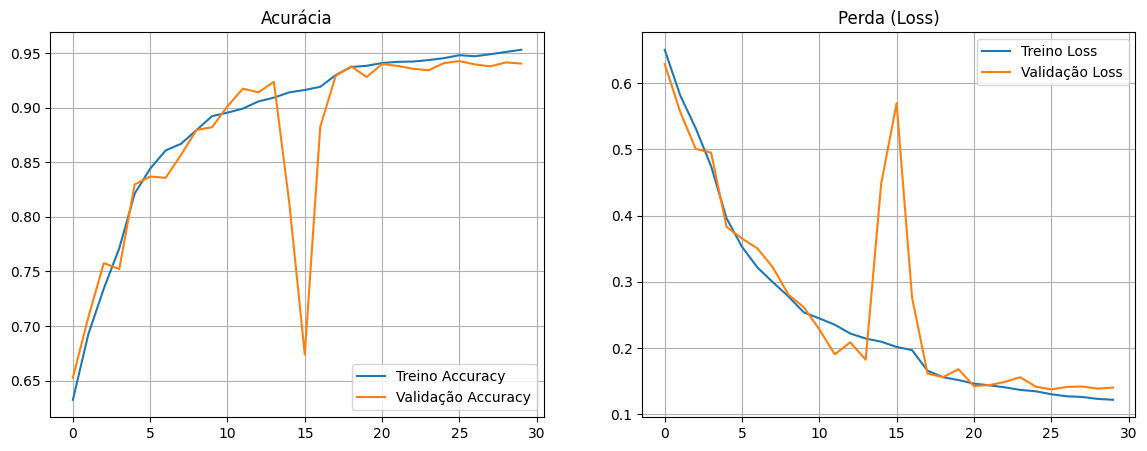


📊 Gerando Matriz de Confusão...
              precision    recall  f1-score   support

        cats       0.95      0.93      0.94      2500
        dogs       0.93      0.96      0.94      2500

    accuracy                           0.94      5000
   macro avg       0.94      0.94      0.94      5000
weighted avg       0.94      0.94      0.94      5000



2025-12-13 15:57:33.244309: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


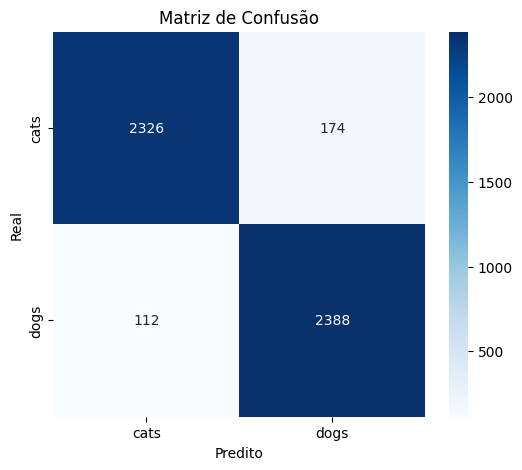

In [9]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Treino Accuracy')
plt.plot(epochs_range, val_acc, label='Validação Accuracy')
plt.title('Acurácia')
plt.legend(loc='lower right')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Treino Loss')
plt.plot(epochs_range, val_loss, label='Validação Loss')
plt.title('Perda (Loss)')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

print("\n📊 Gerando Matriz de Confusão...")

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy().flatten())
    y_pred.extend((preds > 0.5).astype(int).flatten())

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()


## 8. Modo de teste interativo

Por fim, definimos o `loop_teste()` que permite enviar imagens manualmente (via upload no Colab)
para o modelo classificar como **gato** ou **cachorro**, mostrando também a confiança da predição.



🖼️ MODO DE TESTE INTERATIVO
As imagens serão carregadas automaticamente de: /mnt/c/Users/gugsh/Repos/Estudos/IA/Lista DeepLearning/new_images
Processando 8 imagem(ns)...


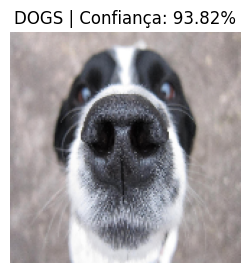

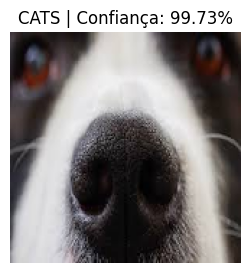

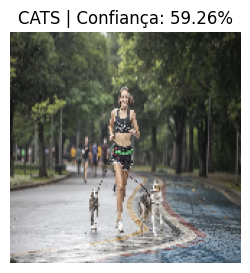

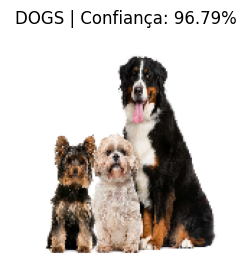

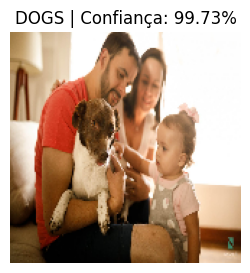

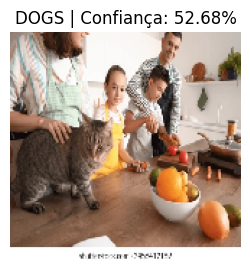

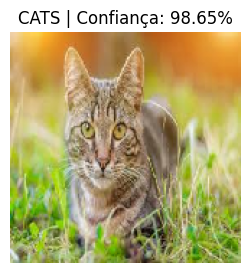

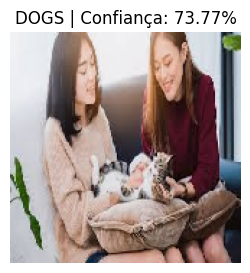

In [ ]:
TEST_IMAGES_DIR = "/mnt/c/Users/gugsh/Repos/Estudos/IA/Lista DeepLearning/new_images"


def _listar_imagens_teste():
    arquivos = []
    if not os.path.isdir(TEST_IMAGES_DIR):
        return arquivos
    for nome in os.listdir(TEST_IMAGES_DIR):
        caminho = os.path.join(TEST_IMAGES_DIR, nome)
        if os.path.isfile(caminho) and nome.lower().endswith(IMG_EXTENSIONS):
            arquivos.append(caminho)
    return sorted(arquivos)


def loop_teste():
    print("\n🖼️ MODO DE TESTE INTERATIVO")
    print(f"As imagens serão carregadas automaticamente de: {TEST_IMAGES_DIR}")

    while True:
        imagens_para_processar = _listar_imagens_teste()
        if not imagens_para_processar:
            print("Nenhuma imagem encontrada em new_images. Adicione arquivos e execute novamente.")
            break

        print(f"Processando {len(imagens_para_processar)} imagem(ns)...")
        for path in imagens_para_processar:
            img = load_img(path, target_size=IMG_SIZE)
            plt.figure(figsize=(3, 3))
            plt.imshow(img)
            plt.axis("off")

            x = img_to_array(img)
            x = np.expand_dims(x, axis=0)

            pred = model.predict(x, verbose=0)[0][0]
            idx = int(pred > 0.5)
            label = class_names[idx].upper()
            confianca = pred if idx == 1 else (1 - pred)

            plt.title(f"{label} | Confiança: {confianca:.2%}")
            plt.show()

        continuar = input("Deseja testar novas imagens (coloque-as na pasta antes)? (s/n): ").lower()
        if continuar != "s":
            print("👋 Encerrando testes.")
            break


loop_teste()
